In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')
df.columns = [
    'Date', 'Rented Bike Count', 'Hour', 'Temperature', 'Humidity', 
    'Wind speed', 'Visibility', 'Dew point', 'Solar Radiation', 
    'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning Day'
]

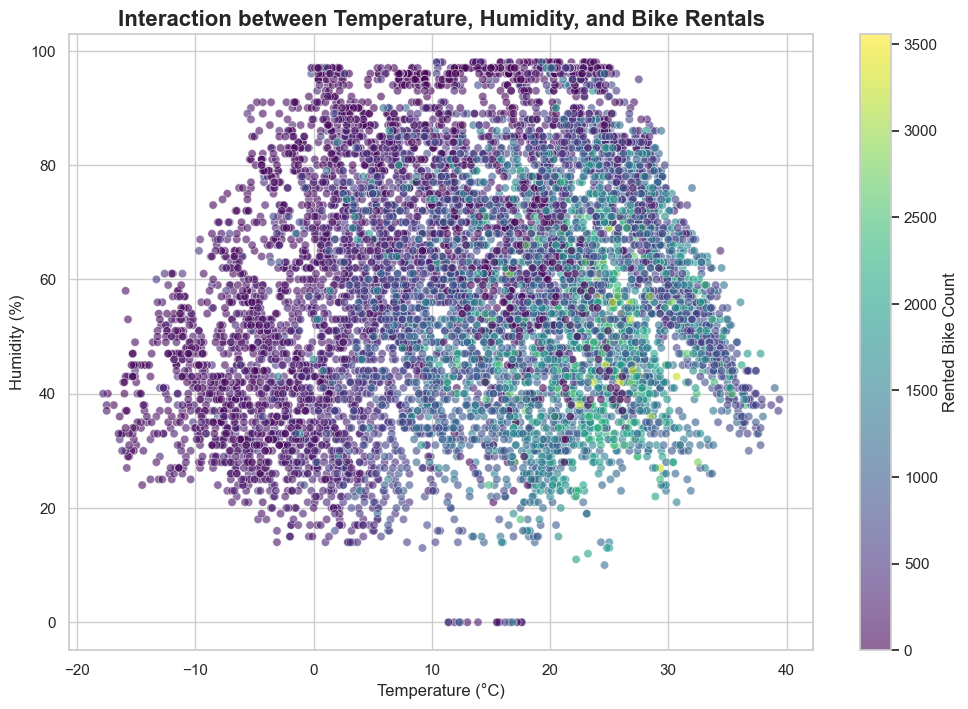

In [ ]:
# 1. [수치형 vs 수치형 (+수치형)] 기온·습도에 따른 대여량 분포
plt.figure(figsize=(12, 8))

scatter = plt.scatter(df['Temperature'], df['Humidity'], 
                      c=df['Rented Bike Count'], 
                      cmap='viridis', 
                      alpha=0.6, 
                      edgecolors='w', 
                      linewidth=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label('Rented Bike Count', fontsize=12)
plt.title('Interaction between Temperature, Humidity, and Bike Rentals', fontsize=16, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)
plt.show()

C:\Users\ellie\AppData\Local\Temp\ipykernel_32444\1855056819.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Temp_Category', y='Rented Bike Count', data=df, palette='Blues')


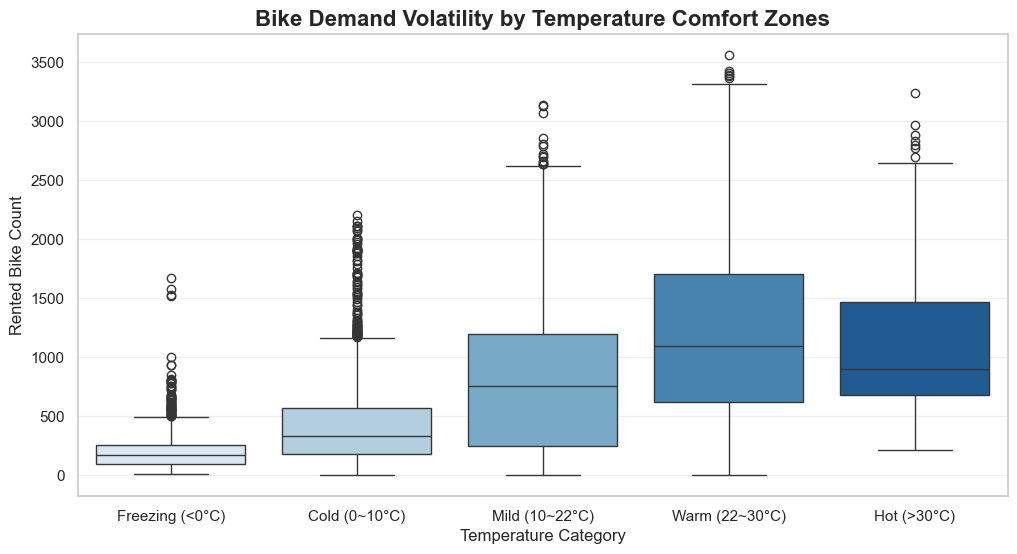

In [ ]:
# 2. [범주형 vs 수치형] 기온 구간별 자전거 대여량 분포 분석
bins = [-30, 0, 10, 22, 30, 40]
labels = ['Freezing (<0°C)', 'Cold (0~10°C)', 'Mild (10~22°C)', 'Warm (22~30°C)', 'Hot (>30°C)']
df['Temp_Category'] = pd.cut(df['Temperature'], bins=bins, labels=labels)

plt.figure(figsize=(12, 6))

sns.boxplot(x='Temp_Category', y='Rented Bike Count', data=df, palette='Blues')

plt.title('Bike Demand Volatility by Temperature Comfort Zones', fontsize=16, fontweight='bold')
plt.xlabel('Temperature Category', fontsize=12)
plt.ylabel('Rented Bike Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

--- 1. 교차표 (Seasons vs Hour 빈도수) ---


Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Seasons,,,,,,,,,,,,,,,,,,,,,
Spring,92,92,92,92,92,92,92,92,92,92,...,92,92,92,92,92,92,92,92,92,92
Summer,92,92,92,92,92,92,92,92,92,92,...,92,92,92,92,92,92,92,92,92,92
Autumn,91,91,91,91,91,91,91,91,91,91,...,91,91,91,91,91,91,91,91,91,91
Winter,90,90,90,90,90,90,90,90,90,90,...,90,90,90,90,90,90,90,90,90,90


--- 2. 상대도수표 (계절별 시간대 비율) ---


Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Seasons,,,,,,,,,,,,,,,,,,,,,
Spring,21.9%,21.1%,20.7%,20.4%,20.1%,20.6%,22.1%,25.0%,25.2%,25.6%,...,30.1%,29.5%,29.2%,28.3%,27.7%,25.7%,24.5%,24.4%,24.0%,22.9%
Summer,41.9%,41.3%,42.3%,42.5%,42.5%,44.6%,42.6%,37.5%,35.2%,35.5%,...,29.7%,30.7%,31.8%,33.8%,35.8%,39.8%,42.5%,42.9%,42.8%,43.3%
Autumn,28.7%,28.4%,27.4%,27.7%,27.9%,25.8%,27.4%,28.9%,29.4%,29.1%,...,31.0%,31.0%,30.8%,30.5%,29.3%,28.1%,27.4%,27.0%,27.2%,27.4%
Winter,7.5%,9.2%,9.6%,9.4%,9.4%,9.1%,8.0%,8.5%,10.2%,9.7%,...,9.2%,8.9%,8.2%,7.4%,7.2%,6.3%,5.6%,5.7%,6.0%,6.4%


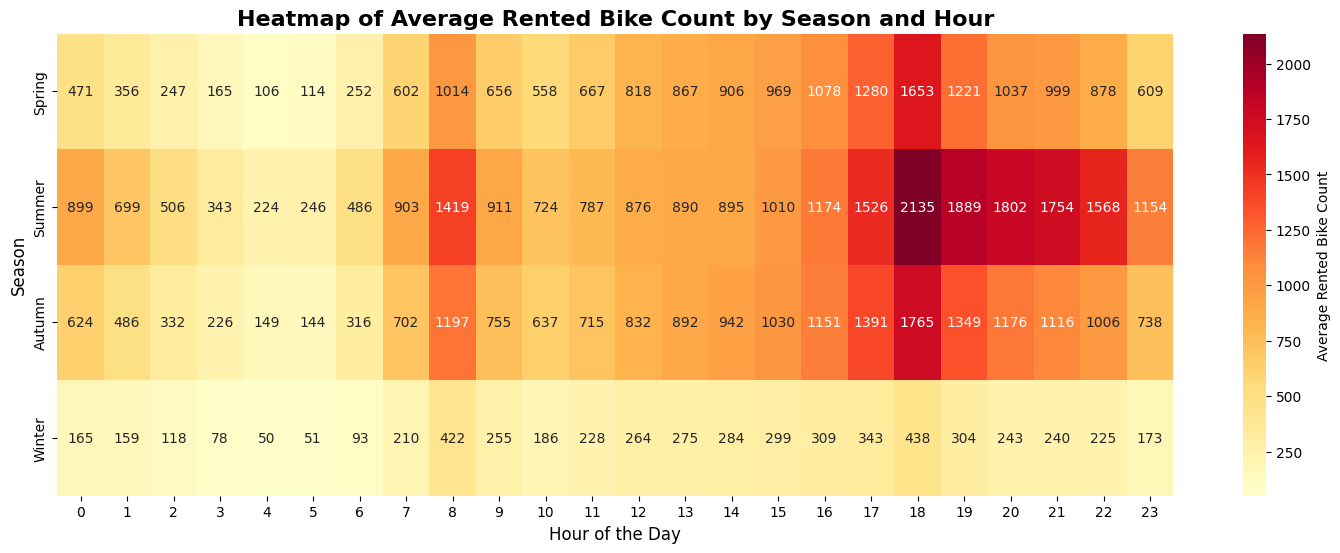

In [12]:
# 3. [범주형 vs 범주형 (+수치형)] 계절·시간대별 대여량 밀도 분석

df.columns = [col.split('(')[0].strip() if '(' in col else col for col in df.columns]

heatmap_data = df.pivot_table(index='Seasons', columns='Hour', values='Rented Bike Count', aggfunc='mean')

season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
heatmap_data = heatmap_data.reindex(season_order)

# 교차표 (Cross-tabulation) 출력
cross_tab = pd.crosstab(index=df['Seasons'], columns=df['Hour'])
cross_tab = cross_tab.reindex(season_order)

print("--- 1. 교차표 (Seasons vs Hour 빈도수) ---")
display(cross_tab)

# 상대도수표 (Relative Frequency Table) 출력
relative_freq_tab = pd.crosstab(
    index=df['Seasons'], 
    columns=df['Hour'], 
    values=df['Rented Bike Count'],
    aggfunc='sum',
    normalize='columns'
)

# 계절 순서 정렬
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
relative_freq_tab = relative_freq_tab.reindex(season_order)

# (선택) 퍼센트로 예쁘게 보기
styled_tab = (relative_freq_tab * 100).round(1).astype(str) + '%'

print("--- 2. 상대도수표 (계절별 시간대 비율) ---")
display(styled_tab)

plt.figure(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".0f", cbar_kws={'label': 'Average Rented Bike Count'})

plt.title('Heatmap of Average Rented Bike Count by Season and Hour', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Season', fontsize=12)
plt.show()

--- 1. 데이터 개수 (교차표) ---
Is Weekend         Weekday  Weekend
Time Category                      
Afternoon (12-17)     1566      624
Evening (18-23)       1566      624
Morning (06-11)       1566      624
Night (00-05)         1566      624

--- 2. 시간대별 평일/주말 대여량 평균 ---
Is Weekend         Weekday  Weekend
Time Category                      
Afternoon (12-17)    803.2    961.4
Evening (18-23)     1117.7    934.1
Morning (06-11)      693.0    415.8
Night (00-05)        263.9    358.1


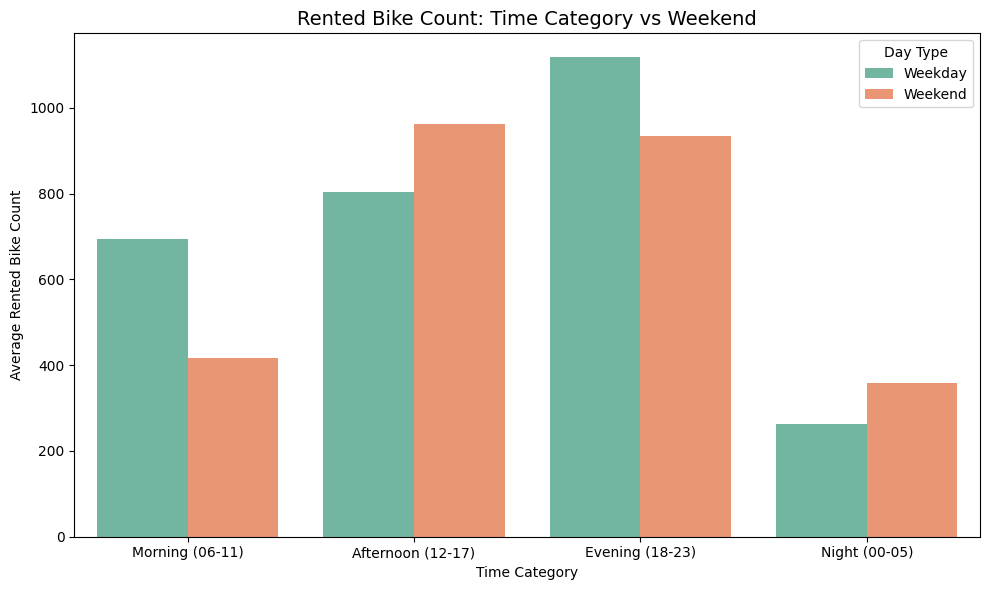

In [ ]:
# 4. [범주형] vs [범주형] 평일/주말과 시간대별 이용 패턴 및 교차 분석

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Is Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).map({True: 'Weekend', False: 'Weekday'})

# Hour 변환 후 '시간대(Time Category)' 범주 생성
def get_time_category(hour):
    if 6 <= hour < 12: return 'Morning (06-11)'
    elif 12 <= hour < 18: return 'Afternoon (12-17)'
    elif 18 <= hour < 24: return 'Evening (18-23)'
    else: return 'Night (00-05)'
df['Time Category'] = df['Hour'].apply(get_time_category)


# 교차표 및 확률표 출력
print("--- 1. 데이터 개수 (교차표) ---")
print(pd.crosstab(df['Time Category'], df['Is Weekend']))

print("\n--- 2. 시간대별 평일/주말 대여량 평균 ---")
avg_rent = df.pivot_table(index='Time Category', columns='Is Weekend', values='Rented Bike Count', aggfunc='mean')
print(avg_rent.round(1))

plt.figure(figsize=(10, 6))

sns.barplot(data=df, x='Time Category', y='Rented Bike Count', hue='Is Weekend', 
            palette='Set2', errorbar=None, 
            order=['Morning (06-11)', 'Afternoon (12-17)', 'Evening (18-23)', 'Night (00-05)'])

plt.title('Rented Bike Count: Time Category vs Weekend', fontsize=14)
plt.xlabel('Time Category')
plt.ylabel('Average Rented Bike Count')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()